In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Internet se seedha German Credit Dataset load kar rahe hain
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/statlog/german/german.data"

# Dataset me column names nahi hote, toh hum khud define kar rahe hain
columns = [
    'checking_account', 'duration_months', 'credit_history', 'purpose', 'credit_amount',
    'savings_account', 'employment_status', 'installment_rate', 'personal_status', 'other_debtors',
    'residence_since', 'property', 'age', 'other_installment_plans', 'housing',
    'existing_credits', 'job', 'num_dependents', 'telephone', 'foreign_worker', 'credit_risk'
]

# Dataframe load karna
df = pd.read_csv(url, sep=' ', names=columns)

# Target variable ko clean karna: 1 = Good Credit, 2 = Bad Credit hota hai isme
# Hum isko standard bana dete hain: 1 = Good (Creditworthy), 0 = Bad
df['credit_risk'] = df['credit_risk'].replace({1: 1, 2: 0})

# Data ka ek chota sa preview dekhne ke liye
print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (1000, 21)


,checking_account,duration_months,credit_history,purpose,credit_amount,savings_account,employment_status,installment_rate,personal_status,other_debtors,...,property,age,other_installment_plans,housing,existing_credits,job,num_dependents,telephone,foreign_worker,credit_risk
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,1
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,0
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,1
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,A122,45,A143,A153,1,A173,2,A191,A201,1
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,A124,53,A143,A153,2,A173,2,A191,A201,0


In [3]:
# to know data structure and data type

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   checking_account         1000 non-null   object
 1   duration_months          1000 non-null   int64 
 2   credit_history           1000 non-null   object
 3   purpose                  1000 non-null   object
 4   credit_amount            1000 non-null   int64 
 5   savings_account          1000 non-null   object
 6   employment_status        1000 non-null   object
 7   installment_rate         1000 non-null   int64 
 8   personal_status          1000 non-null   object
 9   other_debtors            1000 non-null   object
 10  residence_since          1000 non-null   int64 
 11  property                 1000 non-null   object
 12  age                      1000 non-null   int64 
 13  other_installment_plans  1000 non-null   object
 14  housing                  1000 non-null   

credit_risk
1    700
0    300
Name: count, dtype: int64


C:\Users\athde\AppData\Local\Temp\ipykernel_4160\2336469753.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='credit_risk', data=df, palette='Set2')


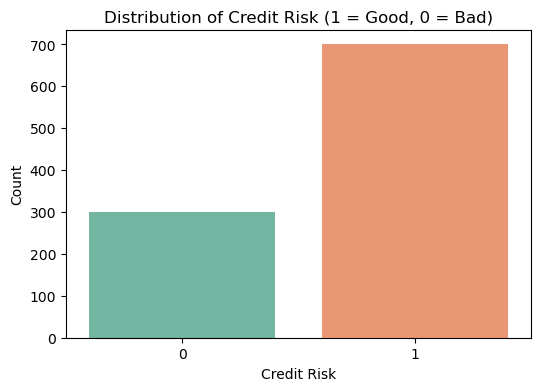

In [5]:
 # Yeh check karne ke liye ki hamare paas kitne Good aur Bad customers hain
print(df['credit_risk'].value_counts())

# Isko ek graph (countplot) par plot karte hain
plt.figure(figsize=(6,4))
sns.countplot(x='credit_risk', data=df, palette='Set2')
plt.title('Distribution of Credit Risk (1 = Good, 0 = Bad)')
plt.xlabel('Credit Risk')
plt.ylabel('Count')
plt.show()

In [6]:
# 'credit_risk' hamara target hai, toh usse alag rakh kar baaki saare text columns ko encode karenge
# target variable ko drop karke features ko encode karte hain
X = df.drop(columns=['credit_risk'])
y = df['credit_risk']

# pd.get_dummies text data ko numbers (0 and 1) me badal dega
X_encoded = pd.get_dummies(X, drop_first=True)

# Dekhte hain ki naye encoded data ka shape kya hai aur woh kaisa dikhta hai
print("Encoded Features Shape:", X_encoded.shape)
X_encoded.head()

Encoded Features Shape: (1000, 48)


,duration_months,credit_amount,installment_rate,residence_since,age,existing_credits,num_dependents,checking_account_A12,checking_account_A13,checking_account_A14,...,property_A124,other_installment_plans_A142,other_installment_plans_A143,housing_A152,housing_A153,job_A172,job_A173,job_A174,telephone_A192,foreign_worker_A202
0,6,1169,4,4,67,2,1,False,False,False,...,False,False,True,True,False,False,True,False,True,False
1,48,5951,2,2,22,1,1,True,False,False,...,False,False,True,True,False,False,True,False,False,False
2,12,2096,2,3,49,1,2,False,False,True,...,False,False,True,True,False,True,False,False,False,False
3,42,7882,2,4,45,1,2,False,False,False,...,False,False,True,False,True,False,True,False,False,False
4,24,4870,3,4,53,2,2,False,False,False,...,True,False,True,False,True,False,True,False,False,False


In [8]:
from sklearn.model_selection import train_test_split

# Data ko 80% training aur 20% testing me split kar rahe hain
# random_state=42 isliye taaki har baar run karne par same result aaye
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

print("Training data features shape:", X_train.shape)
print("Testing data features shape:", X_test.shape)
print("Training labels shape:", y_train.shape)
print("Testing labels shape:", y_test.shape)

Training data features shape: (800, 48)
Testing data features shape: (200, 48)
Training labels shape: (800,)
Testing labels shape: (200,)


In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

# 1. Logistic Regression model ka ek object banana
lr_model = LogisticRegression(max_iter=1000, random_state=42)

# 2. Model ko train karna (Fitting the model)
lr_model.fit(X_train, y_train)

# 3. Test data par predict karna
y_pred_lr = lr_model.predict(X_test)

# Predict probability (Yeh ROC-AUC score nikalne ke liye zaroori hai)
y_pred_prob_lr = lr_model.predict_proba(X_test)[:, 1]

print("--- Logistic Regression Model Model trained successfully---")

--- Logistic Regression Model Model trained successfully---


C:\Users\athde\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [10]:
# Accuracy score dekhne ke liye
print("Accuracy Score:", accuracy_score(y_test, y_pred_lr))

# Task List ke mutabik Precision, Recall, F1-Score dekhne ke liye
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred_lr))

# Task List ke mutabik ROC-AUC Score dekhne ke liye
lr_auc = roc_auc_score(y_test, y_pred_prob_lr)
print(f"ROC-AUC Score: {lr_auc:.4f}")

Accuracy Score: 0.795

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.68      0.58      0.62        59
           1       0.83      0.89      0.86       141

    accuracy                           0.80       200
   macro avg       0.76      0.73      0.74       200
weighted avg       0.79      0.80      0.79       200

ROC-AUC Score: 0.8173


In [11]:
from sklearn.tree import DecisionTreeClassifier

# 1. Decision Tree model ka object banana
dt_model = DecisionTreeClassifier(max_depth=5, random_state=42) # depth limit rakhi hai taaki overfit na ho

# 2. Model ko train karna
dt_model.fit(X_train, y_train)

# 3. Test data par predict karna
y_pred_dt = dt_model.predict(X_test)
y_pred_prob_dt = dt_model.predict_proba(X_test)[:, 1]

# 4. Results print karna
print("--- Decision Tree Model Report ---")
print("Accuracy Score:", accuracy_score(y_test, y_pred_dt))
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred_dt))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred_prob_dt):.4f}")

--- Decision Tree Model Report ---
Accuracy Score: 0.73

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.55      0.49      0.52        59
           1       0.80      0.83      0.81       141

    accuracy                           0.73       200
   macro avg       0.67      0.66      0.67       200
weighted avg       0.72      0.73      0.73       200

ROC-AUC Score: 0.7453


In [12]:
from sklearn.ensemble import RandomForestClassifier

# 1. Random Forest model ka object banana (100 trees ke saath)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# 2. Model ko train karna
rf_model.fit(X_train, y_train)

# 3. Test data par predict karna
y_pred_rf = rf_model.predict(X_test)
y_pred_prob_rf = rf_model.predict_proba(X_test)[:, 1]

# 4. Results print karna
print("--- Random Forest Model Report ---")
print("Accuracy Score:", accuracy_score(y_test, y_pred_rf))
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred_rf))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred_prob_rf):.4f}")

--- Random Forest Model Report ---
Accuracy Score: 0.755

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.65      0.37      0.47        59
           1       0.78      0.91      0.84       141

    accuracy                           0.76       200
   macro avg       0.71      0.64      0.66       200
weighted avg       0.74      0.76      0.73       200

ROC-AUC Score: 0.7910


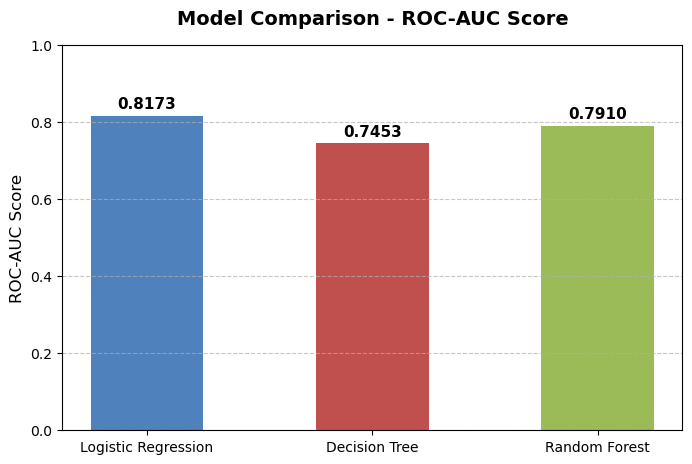

In [13]:
import matplotlib.pyplot as plt

# Teeno models ke naam aur unke ROC-AUC scores
models = ['Logistic Regression', 'Decision Tree', 'Random Forest']
auc_scores = [0.8173, 0.7453, 0.7910]

# Bar plot banana
plt.figure(figsize=(8, 5))
bars = plt.bar(models, auc_scores, color=['#4F81BD', '#C0504D', '#9BBB59'], width=0.5)

# Bars ke upar exact text numbers likhna
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f"{yval:.4f}", ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.ylim(0, 1.0)
plt.title('Model Comparison - ROC-AUC Score', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('ROC-AUC Score', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Graph show karna
plt.show()



